# Fase 2 - Análisis de Pagos y Propinas: ¿Quién deja propina y por qué?

**Pregunta de negocio:** ¿Quién deja propina y por qué? ¿Cómo se relacionan los métodos de pago con las propinas?

## Objetivos de este notebook

1. Analizar la distribución de tipos de pago
2. Entender el sesgo fundamental: las propinas solo se registran en pagos con tarjeta
3. Analizar la propina como porcentaje de la tarifa
4. Explorar cómo varía la propina por hora del día y día de la semana
5. Analizar los códigos de tarifa (rate codes) y su relación con pagos
6. Estudiar la adopción de tarjeta de crédito a lo largo de 2015

## ¿Por qué importa este análisis?

Las propinas representan una parte significativa del ingreso de los conductores.
Entender los factores que influyen en las propinas ayuda a:
- Optimizar los ingresos de los conductores
- Mejorar la experiencia del pasajero
- Identificar patrones de comportamiento del consumidor

## 1. Configuración e importaciones

In [1]:
# Conexión a BigQuery
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


In [2]:
# Librerías de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Distribución de tipos de pago

Los tipos de pago registrados en el dataset son:
- **1 = Tarjeta de crédito:** Pago electrónico, propina registrada
- **2 = Efectivo:** Pago en metálico, propina NO registrada
- **3 = Sin cargo:** Viaje gratuito (cortesía, error)
- **4 = Disputa:** Viaje en disputa/contestado

Esta clasificación es crucial porque determina si la propina queda registrada.

In [3]:
query_payments = """
SELECT
    payment_type,
    rate_code,
    fare_amount,
    tip_amount,
    total_amount,
    trip_distance,
    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
    EXTRACT(DAYOFWEEK FROM pickup_datetime) AS day_of_week,
    EXTRACT(MONTH FROM pickup_datetime) AS month,
    CASE
        WHEN fare_amount > 0
        THEN (tip_amount / fare_amount) * 100
        ELSE NULL
    END AS tip_pct
FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    fare_amount > 0
    AND fare_amount < 200
    AND trip_distance > 0
    AND trip_distance < 50
    AND payment_type IN ('1', '2', '3', '4')
    AND pickup_datetime >= '2015-01-01'
    AND pickup_datetime < '2016-01-01'
ORDER BY RAND()
LIMIT 200000
"""

df = bq.query_to_df(query_payments)
print(f"Registros cargados: {len(df):,}")
df.head()

📁 Cache hit: b9e2718fac32.parquet (200,000 filas)
Registros cargados: 200,000


,payment_type,rate_code,fare_amount,tip_amount,total_amount,trip_distance,pickup_hour,day_of_week,month,tip_pct
0,1,1,6.50,1.00,8.30,1.10,11,1,11,15.38
1,1,1,7.50,4.00,12.80,1.40,5,2,5,53.33
2,1,2,52.00,0.00,58.13,19.66,14,4,3,0.00
3,1,1,9.50,2.00,12.80,2.43,23,6,3,21.05
4,2,1,3.00,0.00,3.80,0.24,14,7,8,0.00


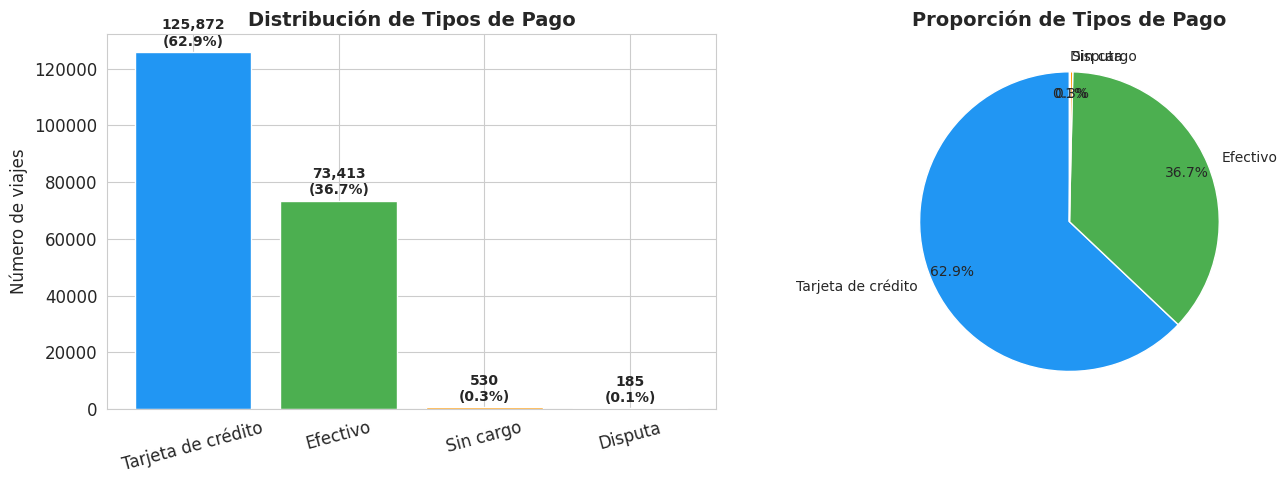

In [4]:
# Mapeo de etiquetas
payment_labels = {
    '1': 'Tarjeta de crédito',
    '2': 'Efectivo',
    '3': 'Sin cargo',
    '4': 'Disputa'
}

rate_labels = {
    '1': 'Estándar',
    '2': 'JFK',
    '3': 'Newark',
    '4': 'Nassau/Westchester',
    '5': 'Negociada',
    '6': 'Grupo'
}

df['payment_label'] = df['payment_type'].astype(str).map(payment_labels)
df['rate_label'] = df['rate_code'].astype(str).map(rate_labels)

# Distribución de tipos de pago
payment_dist = df['payment_label'].value_counts()
payment_pct = df['payment_label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors_pay = ['#2196F3', '#4CAF50', '#FF9800', '#E53935']
order = ['Tarjeta de crédito', 'Efectivo', 'Sin cargo', 'Disputa']
existing_order = [o for o in order if o in payment_dist.index]

bars = axes[0].bar(range(len(existing_order)), 
                   [payment_dist[o] for o in existing_order],
                   color=colors_pay[:len(existing_order)], edgecolor='white')
axes[0].set_xticks(range(len(existing_order)))
axes[0].set_xticklabels(existing_order, rotation=15)
axes[0].set_title('Distribución de Tipos de Pago', fontweight='bold')
axes[0].set_ylabel('Número de viajes')

for bar, label in zip(bars, existing_order):
    count = payment_dist[label]
    pct = payment_pct[label]
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + payment_dist.max() * 0.01,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico de pastel
axes[1].pie([payment_dist[o] for o in existing_order], 
            labels=existing_order,
            colors=colors_pay[:len(existing_order)],
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.85,
            textprops={'fontsize': 10})
axes[1].set_title('Proporción de Tipos de Pago', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Insight clave: Las propinas solo se registran con tarjeta de crédito

Este es uno de los **sesgos más importantes** del dataset.
Cuando un pasajero paga en efectivo, la propina se entrega directamente al conductor
y **no queda registrada en el sistema**. Por lo tanto:

- `tip_amount = 0` para efectivo **no significa** que no hubo propina
- Solo podemos analizar propinas de forma fiable para pagos con tarjeta
- Cualquier modelo predictivo de propinas debe considerar este sesgo

In [5]:
# Demostrar el sesgo: tip_amount por tipo de pago
tip_by_payment = df.groupby('payment_label').agg(
    tip_mean=('tip_amount', 'mean'),
    tip_median=('tip_amount', 'median'),
    tip_zero_pct=('tip_amount', lambda x: (x == 0).mean() * 100),
    count=('tip_amount', 'count')
).round(2)

print("PROPINAS POR TIPO DE PAGO")
print("=" * 70)
print(tip_by_payment)
print("\n" + "=" * 70)
print("CONCLUSIÓN CLAVE:")
print("Los pagos en efectivo muestran ~100% de propinas en $0.00 porque")
print("el sistema NO registra propinas en efectivo. Esto es un SESGO DE")
print("REGISTRO, no un reflejo del comportamiento real del pasajero.")
print("=" * 70)

PROPINAS POR TIPO DE PAGO
                    tip_mean  tip_median  tip_zero_pct   count
payment_label                                                 
Disputa                 0.00        0.00        100.00     185
Efectivo                0.00        0.00        100.00   73413
Sin cargo               0.00        0.00        100.00     530
Tarjeta de crédito      2.70        2.00          3.56  125872

CONCLUSIÓN CLAVE:
Los pagos en efectivo muestran ~100% de propinas en $0.00 porque
el sistema NO registra propinas en efectivo. Esto es un SESGO DE
REGISTRO, no un reflejo del comportamiento real del pasajero.


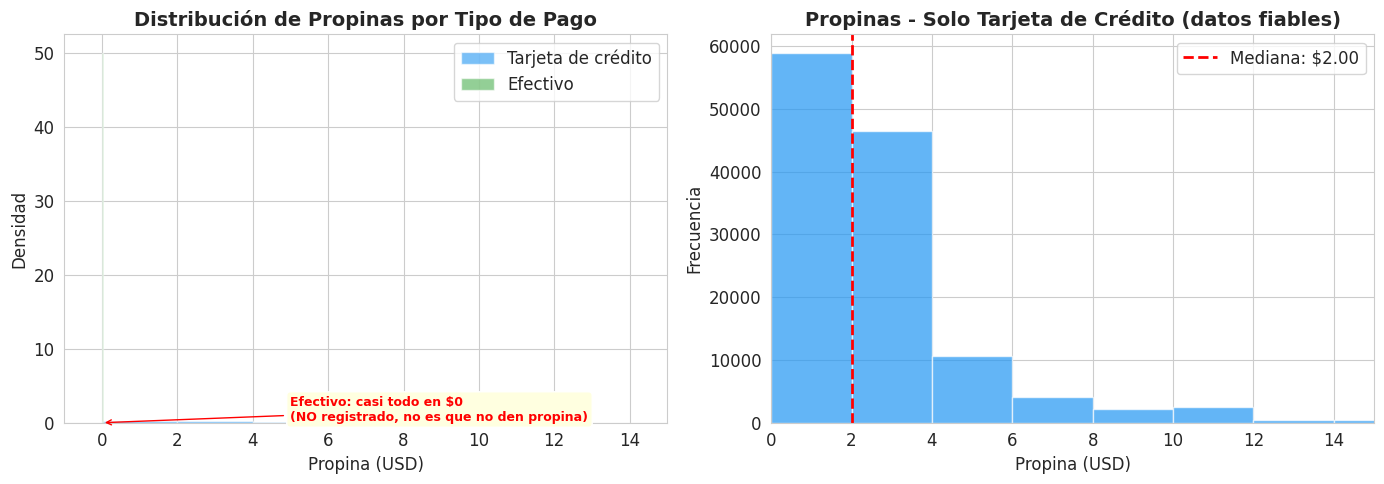

In [6]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de propinas por tipo de pago
for ptype, color in [('Tarjeta de crédito', '#2196F3'), ('Efectivo', '#4CAF50')]:
    data = df[df['payment_label'] == ptype]['tip_amount']
    axes[0].hist(data, bins=50, alpha=0.6, color=color, label=ptype, density=True)

axes[0].set_title('Distribución de Propinas por Tipo de Pago', fontweight='bold')
axes[0].set_xlabel('Propina (USD)')
axes[0].set_ylabel('Densidad')
axes[0].set_xlim(-1, 15)
axes[0].legend()
axes[0].annotate('Efectivo: casi todo en $0\n(NO registrado, no es que no den propina)',
                xy=(0, 0), xytext=(5, 0.3),
                arrowprops=dict(arrowstyle='->', color='red'),
                color='red', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Solo tarjeta de crédito (análisis limpio)
df_credit = df[df['payment_label'] == 'Tarjeta de crédito'].copy()
axes[1].hist(df_credit['tip_amount'], bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
axes[1].set_title('Propinas - Solo Tarjeta de Crédito (datos fiables)', fontweight='bold')
axes[1].set_xlabel('Propina (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 15)

med = df_credit['tip_amount'].median()
axes[1].axvline(med, color='red', linestyle='--', linewidth=2, label=f'Mediana: ${med:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Propina como porcentaje de la tarifa (tip_pct)

Es más informativo analizar la propina como **porcentaje de la tarifa** que en valor
absoluto. Un dólar de propina en un viaje de $5 es generoso; en un viaje de $50, no tanto.

Analizamos solo pagos con tarjeta de crédito (los únicos con datos fiables de propina).

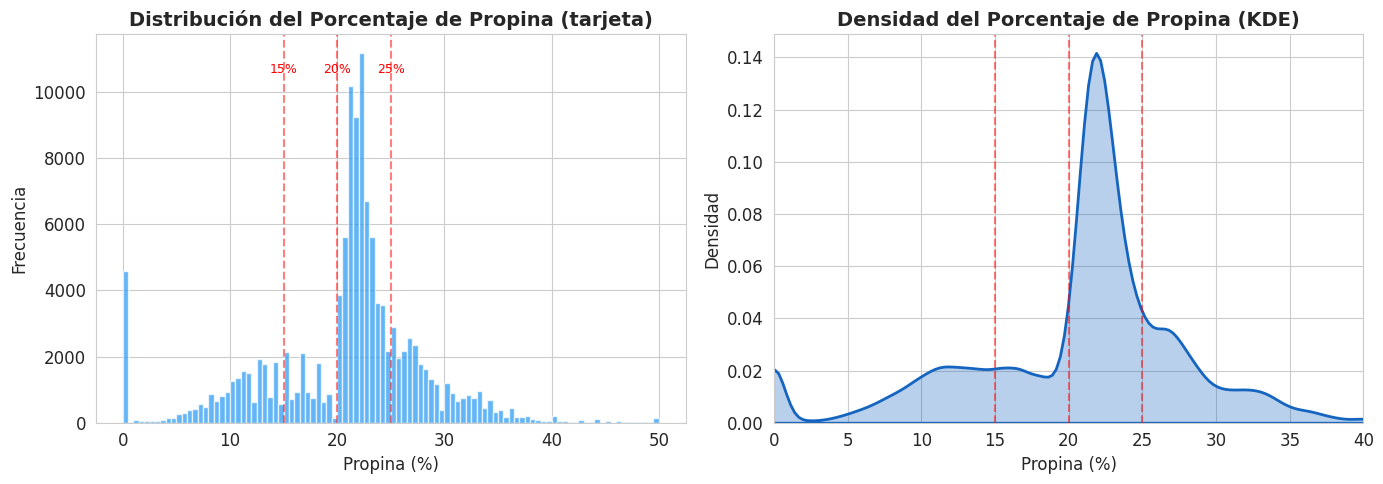


Estadísticas del porcentaje de propina (solo tarjeta de crédito):
  Media:    20.8%
  Mediana:  21.9%
  Moda:     ~22%
  Std:      7.5%

  Picos en 15%, 20% y 25% sugieren que los pasajeros tienden
  a usar porcentajes redondos al calcular la propina.


In [7]:
# Filtrar: solo tarjeta de crédito con tip_pct válido y razonable
df_tip = df_credit[(df_credit['tip_pct'].notna()) & 
                    (df_credit['tip_pct'] >= 0) & 
                    (df_credit['tip_pct'] <= 50)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tip_pct
axes[0].hist(df_tip['tip_pct'], bins=100, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribución del Porcentaje de Propina (tarjeta)', fontweight='bold')
axes[0].set_xlabel('Propina (%)')
axes[0].set_ylabel('Frecuencia')

# Marcar porcentajes comunes
for pct, label in [(15, '15%'), (20, '20%'), (25, '25%')]:
    axes[0].axvline(pct, color='red', linestyle='--', alpha=0.5)
    axes[0].text(pct, axes[0].get_ylim()[1] * 0.9, label, ha='center', 
                fontsize=9, color='red')

# KDE para ver la forma con más detalle
sns.kdeplot(data=df_tip['tip_pct'], ax=axes[1], color='#1565C0', 
            linewidth=2, fill=True, alpha=0.3)
axes[1].set_title('Densidad del Porcentaje de Propina (KDE)', fontweight='bold')
axes[1].set_xlabel('Propina (%)')
axes[1].set_ylabel('Densidad')
axes[1].set_xlim(0, 40)

for pct in [15, 20, 25]:
    axes[1].axvline(pct, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nEstadísticas del porcentaje de propina (solo tarjeta de crédito):")
print(f"  Media:    {df_tip['tip_pct'].mean():.1f}%")
print(f"  Mediana:  {df_tip['tip_pct'].median():.1f}%")
print(f"  Moda:     ~{df_tip['tip_pct'].round().mode().values[0]:.0f}%")
print(f"  Std:      {df_tip['tip_pct'].std():.1f}%")
print(f"\n  Picos en 15%, 20% y 25% sugieren que los pasajeros tienden")
print(f"  a usar porcentajes redondos al calcular la propina.")

## 5. Propina por hora del día y día de la semana

¿Varía la generosidad de los pasajeros según el momento del viaje?
Factores que podrían influir:
- Hora del día (prisa matutina vs relajación nocturna)
- Día de la semana (rutina laboral vs ocio)
- Estado anímico y contexto social

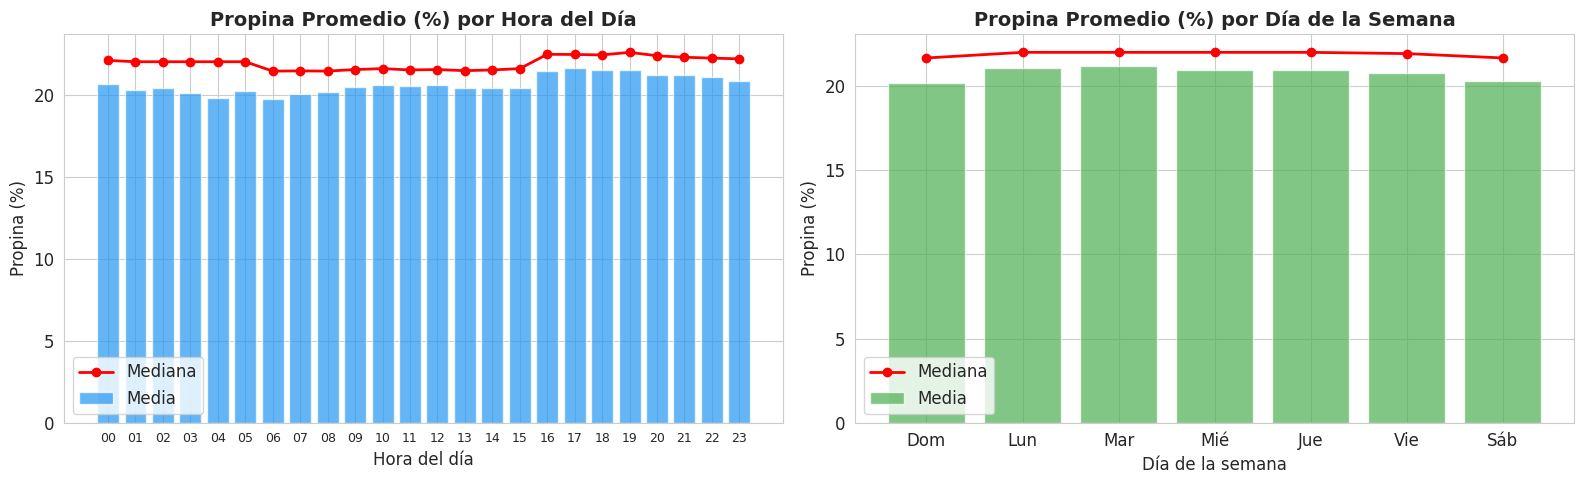

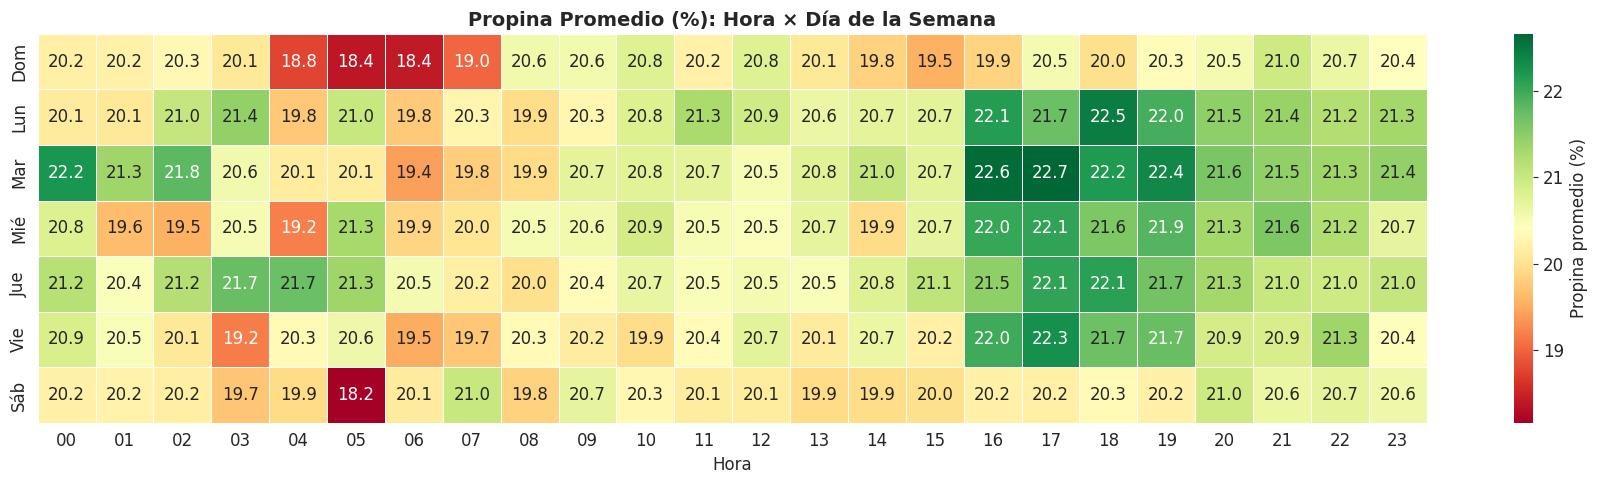

In [8]:
# Tip pct promedio por hora
tip_by_hour = df_tip.groupby('pickup_hour')['tip_pct'].agg(['mean', 'median', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por hora del día
axes[0].bar(tip_by_hour['pickup_hour'], tip_by_hour['mean'], 
            color='#2196F3', alpha=0.7, edgecolor='white', label='Media')
axes[0].plot(tip_by_hour['pickup_hour'], tip_by_hour['median'], 
             color='red', marker='o', linewidth=2, label='Mediana')
axes[0].set_title('Propina Promedio (%) por Hora del Día', fontweight='bold')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Propina (%)')
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h:02d}' for h in range(24)], fontsize=9)
axes[0].legend()

# Por día de la semana
day_labels = ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb']
tip_by_day = df_tip.groupby('day_of_week')['tip_pct'].agg(['mean', 'median']).reset_index()

axes[1].bar(tip_by_day['day_of_week'], tip_by_day['mean'], 
            color='#4CAF50', alpha=0.7, edgecolor='white', label='Media')
axes[1].plot(tip_by_day['day_of_week'], tip_by_day['median'], 
             color='red', marker='o', linewidth=2, label='Mediana')
axes[1].set_title('Propina Promedio (%) por Día de la Semana', fontweight='bold')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Propina (%)')
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)
axes[1].legend()

plt.tight_layout()
plt.show()

# Heatmap hora x día
tip_heatmap = df_tip.groupby(['day_of_week', 'pickup_hour'])['tip_pct'].mean().reset_index()
tip_matrix = tip_heatmap.pivot(index='day_of_week', columns='pickup_hour', values='tip_pct')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    tip_matrix.astype(float),
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    yticklabels=['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'],
    xticklabels=[f'{h:02d}' for h in range(24)],
    linewidths=0.5,
    cbar_kws={'label': 'Propina promedio (%)'},
    ax=ax
)
ax.set_title('Propina Promedio (%): Hora × Día de la Semana', fontweight='bold')
ax.set_xlabel('Hora')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Análisis de códigos de tarifa (Rate Codes)

Los códigos de tarifa definen el tipo de viaje y su estructura de precios:

| Código | Descripción | Precio |
|--------|-------------|--------|
| 1 | Estándar | Por taxímetro |
| 2 | JFK | Tarifa plana $52 |
| 3 | Newark | Precio negociado + peajes |
| 4 | Nassau/Westchester | Fuera de la ciudad |
| 5 | Negociada | Precio acordado |
| 6 | Grupo | Tarifa compartida |

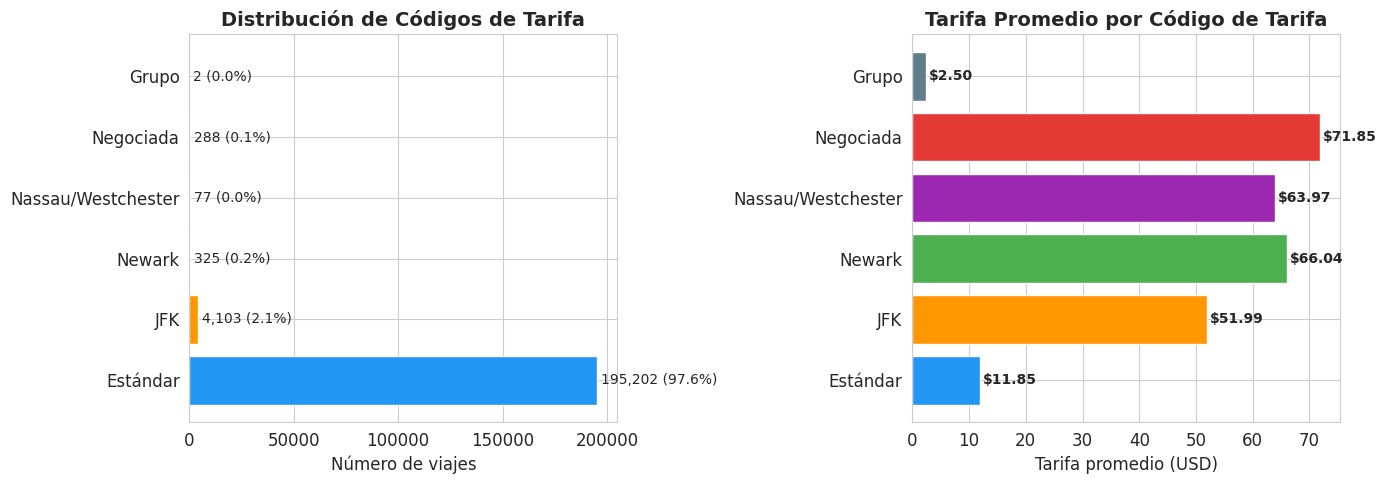

In [9]:
# Distribución de rate codes
rate_dist = df['rate_label'].value_counts()
rate_pct = df['rate_label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de rate codes
rate_colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#E53935', '#607D8B']
rate_order = ['Estándar', 'JFK', 'Newark', 'Nassau/Westchester', 'Negociada', 'Grupo']
existing_rates = [r for r in rate_order if r in rate_dist.index]

axes[0].barh(range(len(existing_rates)), 
             [rate_dist[r] for r in existing_rates],
             color=rate_colors[:len(existing_rates)], edgecolor='white')
axes[0].set_yticks(range(len(existing_rates)))
axes[0].set_yticklabels(existing_rates)
axes[0].set_title('Distribución de Códigos de Tarifa', fontweight='bold')
axes[0].set_xlabel('Número de viajes')

for i, rate in enumerate(existing_rates):
    count = rate_dist[rate]
    pct = rate_pct[rate]
    axes[0].text(count + rate_dist.max() * 0.01, i, f'{count:,} ({pct:.1f}%)', 
                va='center', fontsize=10)

# Tarifa promedio por rate code
fare_by_rate = df.groupby('rate_label')['fare_amount'].mean()
fare_order = [r for r in existing_rates if r in fare_by_rate.index]
axes[1].barh(range(len(fare_order)),
             [fare_by_rate[r] for r in fare_order],
             color=rate_colors[:len(fare_order)], edgecolor='white')
axes[1].set_yticks(range(len(fare_order)))
axes[1].set_yticklabels(fare_order)
axes[1].set_title('Tarifa Promedio por Código de Tarifa', fontweight='bold')
axes[1].set_xlabel('Tarifa promedio (USD)')

for i, rate in enumerate(fare_order):
    axes[1].text(fare_by_rate[rate] + 0.5, i, f'${fare_by_rate[rate]:.2f}', 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Tabla cruzada: Tipo de pago × Código de tarifa

¿Existe relación entre el tipo de viaje y el método de pago?
Por ejemplo, ¿los viajes al aeropuerto (JFK) se pagan más con tarjeta?

In [10]:
# Tabla cruzada de conteos
cross_tab = pd.crosstab(
    df['rate_label'], 
    df['payment_label'],
    margins=True,
    margins_name='Total'
)

print("TABLA CRUZADA: Código de Tarifa × Tipo de Pago (conteos)")
print("=" * 70)
print(cross_tab)

# Tabla cruzada normalizada por fila (porcentajes)
cross_tab_pct = pd.crosstab(
    df['rate_label'], 
    df['payment_label'],
    normalize='index'
) * 100

print("\n\nTABLA CRUZADA: Código de Tarifa × Tipo de Pago (% por fila)")
print("=" * 70)
print(cross_tab_pct.round(1))

TABLA CRUZADA: Código de Tarifa × Tipo de Pago (conteos)
payment_label       Disputa  Efectivo  Sin cargo  Tarjeta de crédito   Total
rate_label                                                                  
Estándar                180     71842        505              122675  195202
Grupo                     0         1          1                   0       2
JFK                       4      1394         16                2689    4103
Nassau/Westchester        0        28          0                  49      77
Negociada                 1        52          5                 230     288
Newark                    0        93          3                 229     325
Total                   185     73410        530              125872  199997


TABLA CRUZADA: Código de Tarifa × Tipo de Pago (% por fila)
payment_label       Disputa  Efectivo  Sin cargo  Tarjeta de crédito
rate_label                                                          
Estándar               0.10     36.80       0.30  

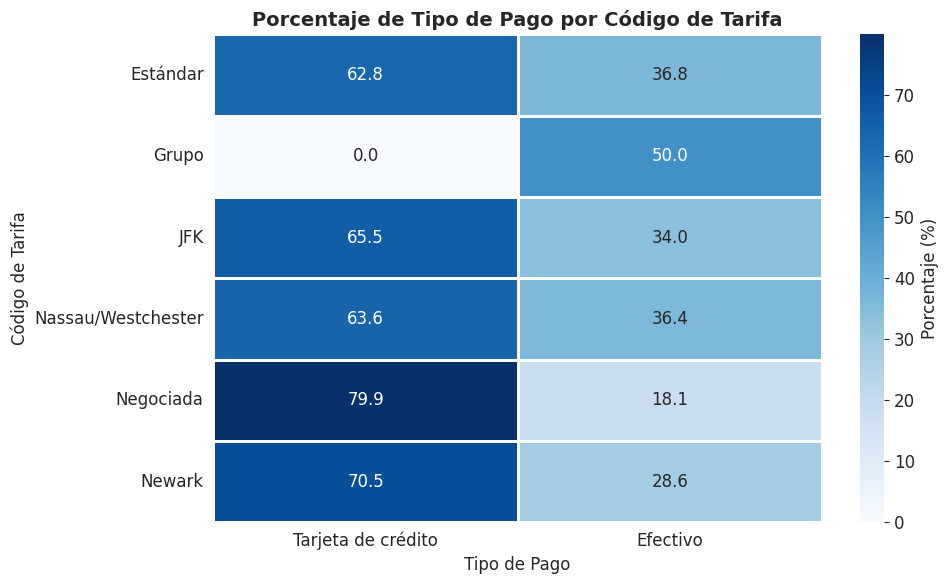


Observaciones:
- Los viajes al JFK y Newark tienen mayor proporción de pago con tarjeta
- Esto tiene sentido: viajeros de aeropuerto tienden a usar tarjeta
- Los viajes estándar muestran una mezcla más equilibrada


In [11]:
# Visualización del cross-tab como heatmap
# Filtrar solo las columnas de interés (tarjeta y efectivo)
cols_interest = [c for c in ['Tarjeta de crédito', 'Efectivo'] if c in cross_tab_pct.columns]
cross_filtered = cross_tab_pct[cols_interest]

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cross_filtered.astype(float),
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Porcentaje (%)'},
    ax=ax
)

ax.set_title('Porcentaje de Tipo de Pago por Código de Tarifa', fontweight='bold')
ax.set_xlabel('Tipo de Pago')
ax.set_ylabel('Código de Tarifa')

plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- Los viajes al JFK y Newark tienen mayor proporción de pago con tarjeta")
print("- Esto tiene sentido: viajeros de aeropuerto tienden a usar tarjeta")
print("- Los viajes estándar muestran una mezcla más equilibrada")

## 8. Propina promedio por código de tarifa

¿Los viajes más largos o especiales (aeropuerto) reciben mejores propinas?
Analizamos solo pagos con tarjeta de crédito.

PROPINA POR CÓDIGO DE TARIFA (solo tarjeta de crédito)
                    tip_pct_mean  tip_pct_median  tip_amount_mean  fare_mean  \
rate_label                                                                     
Estándar                   20.81           21.88             2.47      12.32   
JFK                        19.70           22.37            10.24      51.99   
Newark                     19.31           23.17            12.97      67.09   
Nassau/Westchester         16.80           18.42            12.59      74.67   
Negociada                  15.31           20.05            11.32      75.45   

                     count  
rate_label                  
Estándar            122139  
JFK                   2683  
Newark                 227  
Nassau/Westchester      47  
Negociada              228  


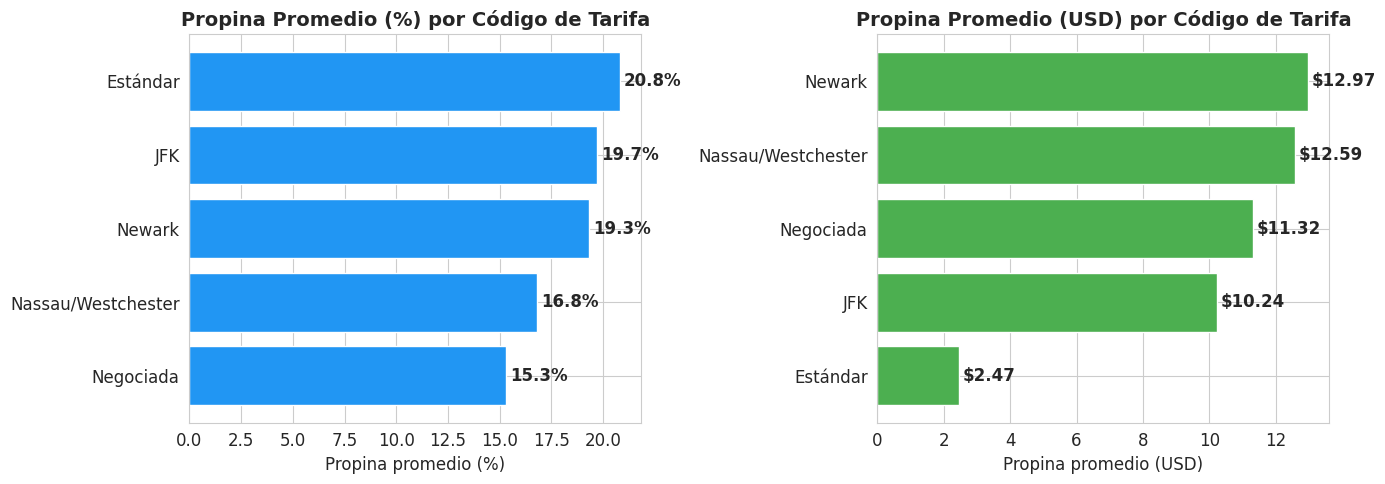

In [12]:
# Solo tarjeta de crédito con tip_pct válido
df_tip_rate = df_credit[
    (df_credit['tip_pct'].notna()) & 
    (df_credit['tip_pct'] >= 0) & 
    (df_credit['tip_pct'] <= 50) &
    (df_credit['rate_label'].notna())
].copy()

tip_by_rate = df_tip_rate.groupby('rate_label').agg(
    tip_pct_mean=('tip_pct', 'mean'),
    tip_pct_median=('tip_pct', 'median'),
    tip_amount_mean=('tip_amount', 'mean'),
    fare_mean=('fare_amount', 'mean'),
    count=('tip_pct', 'count')
).round(2)

print("PROPINA POR CÓDIGO DE TARIFA (solo tarjeta de crédito)")
print("=" * 75)
print(tip_by_rate.sort_values('tip_pct_mean', ascending=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Propina en porcentaje
tip_sorted = tip_by_rate.sort_values('tip_pct_mean', ascending=True)
axes[0].barh(range(len(tip_sorted)), tip_sorted['tip_pct_mean'],
             color='#2196F3', edgecolor='white')
axes[0].set_yticks(range(len(tip_sorted)))
axes[0].set_yticklabels(tip_sorted.index)
axes[0].set_title('Propina Promedio (%) por Código de Tarifa', fontweight='bold')
axes[0].set_xlabel('Propina promedio (%)')

for i, (_, row) in enumerate(tip_sorted.iterrows()):
    axes[0].text(row['tip_pct_mean'] + 0.2, i, f"{row['tip_pct_mean']:.1f}%",
                va='center', fontweight='bold')

# Propina en valor absoluto
tip_sorted_abs = tip_by_rate.sort_values('tip_amount_mean', ascending=True)
axes[1].barh(range(len(tip_sorted_abs)), tip_sorted_abs['tip_amount_mean'],
             color='#4CAF50', edgecolor='white')
axes[1].set_yticks(range(len(tip_sorted_abs)))
axes[1].set_yticklabels(tip_sorted_abs.index)
axes[1].set_title('Propina Promedio (USD) por Código de Tarifa', fontweight='bold')
axes[1].set_xlabel('Propina promedio (USD)')

for i, (_, row) in enumerate(tip_sorted_abs.iterrows()):
    axes[1].text(row['tip_amount_mean'] + 0.1, i, f"${row['tip_amount_mean']:.2f}",
                va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Tendencia: Adopción de tarjeta de crédito durante 2015

¿Creció el uso de tarjeta de crédito a lo largo de 2015?
Esta tendencia es importante porque afecta:
- La cantidad de datos de propina disponibles
- Los ingresos registrados de los conductores
- La digitalización del sector de taxis

In [13]:
# Consulta agregada por mes para mayor precisión
query_monthly_payment = """
SELECT
    EXTRACT(MONTH FROM pickup_datetime) AS month,
    payment_type,
    COUNT(*) AS trip_count
FROM
    `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    pickup_datetime >= '2015-01-01'
    AND pickup_datetime < '2016-01-01'
    AND fare_amount > 0
    AND payment_type IN ('1', '2')
GROUP BY
    month, payment_type
ORDER BY
    month, payment_type
"""

df_monthly_pay = bq.query_to_df(query_monthly_payment)
print(f"Filas obtenidas: {len(df_monthly_pay)}")
df_monthly_pay.head()

📁 Cache hit: 13f6bdfabaaa.parquet (24 filas)
Filas obtenidas: 24


,month,payment_type,trip_count
0,1,1,7878999
1,1,2,4809225
2,2,1,7981692
3,2,2,4406471
4,3,1,8434931


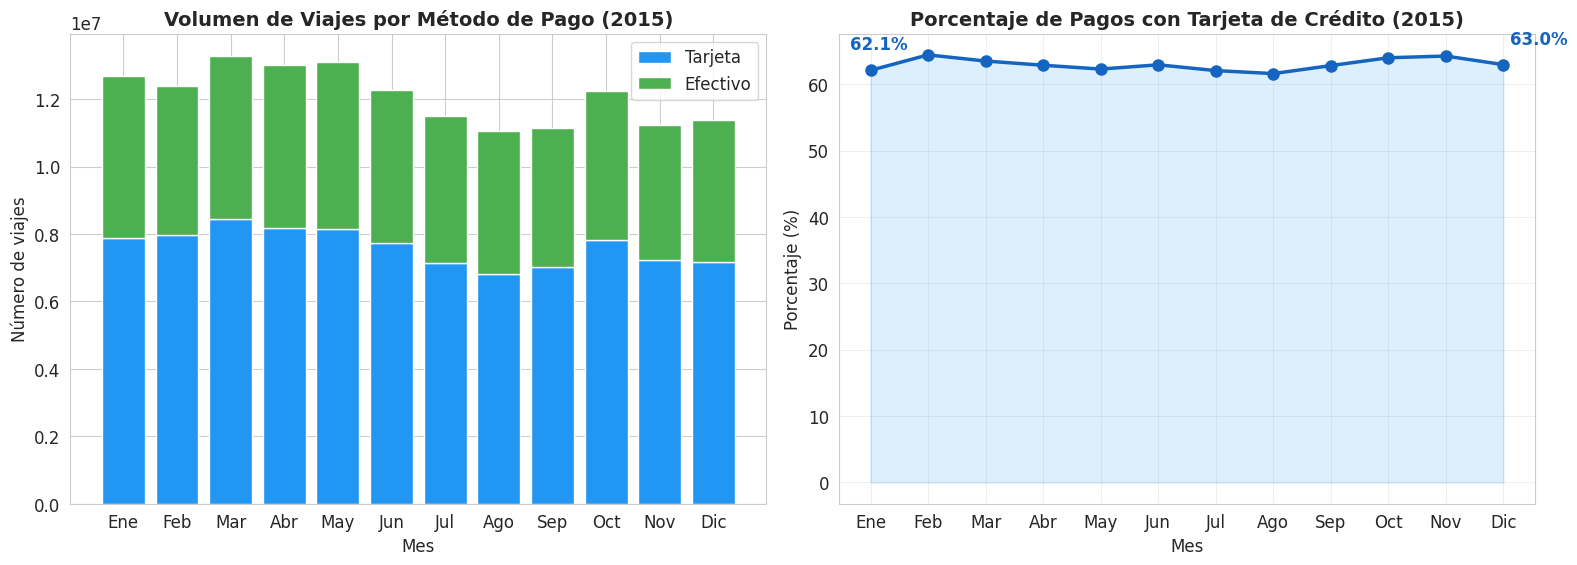


Tendencia de adopción de tarjeta de crédito:
  Enero 2015:     62.1%
  Diciembre 2015: 63.0%
  Cambio:         +0.9 puntos porcentuales


In [14]:
# Calcular porcentaje de tarjeta de crédito por mes
df_monthly_pay['payment_type'] = df_monthly_pay['payment_type'].astype(str)
monthly_pivot = df_monthly_pay.pivot(index='month', columns='payment_type', values='trip_count').fillna(0)

# Renombrar columnas
col_rename = {'1': 'Tarjeta', '2': 'Efectivo'}
monthly_pivot = monthly_pivot.rename(columns=col_rename)

if 'Tarjeta' in monthly_pivot.columns and 'Efectivo' in monthly_pivot.columns:
    monthly_pivot['total'] = monthly_pivot['Tarjeta'] + monthly_pivot['Efectivo']
    monthly_pivot['pct_tarjeta'] = (monthly_pivot['Tarjeta'] / monthly_pivot['total']) * 100

    month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                   'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico de barras apiladas
    x = range(len(monthly_pivot))
    axes[0].bar(x, monthly_pivot['Tarjeta'], color='#2196F3', label='Tarjeta', edgecolor='white')
    axes[0].bar(x, monthly_pivot['Efectivo'], bottom=monthly_pivot['Tarjeta'], 
                color='#4CAF50', label='Efectivo', edgecolor='white')
    axes[0].set_title('Volumen de Viajes por Método de Pago (2015)', fontweight='bold')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel('Número de viajes')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(month_names[:len(monthly_pivot)])
    axes[0].legend()

    # Línea de porcentaje de tarjeta
    axes[1].plot(x, monthly_pivot['pct_tarjeta'], 
                color='#1565C0', marker='o', linewidth=2.5, markersize=8)
    axes[1].fill_between(x, monthly_pivot['pct_tarjeta'], alpha=0.15, color='#2196F3')
    axes[1].set_title('Porcentaje de Pagos con Tarjeta de Crédito (2015)', fontweight='bold')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('Porcentaje (%)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(month_names[:len(monthly_pivot)])
    axes[1].grid(True, alpha=0.3)

    # Anotar inicio y fin
    pct_inicio = monthly_pivot['pct_tarjeta'].iloc[0]
    pct_fin = monthly_pivot['pct_tarjeta'].iloc[-1]
    axes[1].annotate(f'{pct_inicio:.1f}%', xy=(0, pct_inicio), 
                    xytext=(-15, 15), textcoords='offset points',
                    fontweight='bold', color='#1565C0')
    axes[1].annotate(f'{pct_fin:.1f}%', xy=(len(monthly_pivot)-1, pct_fin), 
                    xytext=(5, 15), textcoords='offset points',
                    fontweight='bold', color='#1565C0')

    plt.tight_layout()
    plt.show()

    cambio = pct_fin - pct_inicio
    print(f"\nTendencia de adopción de tarjeta de crédito:")
    print(f"  Enero 2015:     {pct_inicio:.1f}%")
    print(f"  Diciembre 2015: {pct_fin:.1f}%")
    print(f"  Cambio:         {cambio:+.1f} puntos porcentuales")
else:
    print("No se encontraron las columnas esperadas. Verificar datos.")
    print(monthly_pivot.columns.tolist())

## Conclusiones del Análisis de Pagos y Propinas

1. **Sesgo de registro:** Las propinas solo se registran para pagos con tarjeta de crédito. Cualquier análisis de propinas debe filtrar por este tipo de pago.

2. **Porcentajes de propina:** Los pasajeros que pagan con tarjeta tienden a dejar propinas entre el 15% y el 25%, con picos claros en porcentajes redondos. Esto sugiere que la interfaz de pago del taxi ofrece opciones predefinidas.

3. **Patrones temporales de propina:** Las propinas varían ligeramente por hora y día, pero las diferencias son relativamente pequeñas comparadas con la variabilidad individual.

4. **Códigos de tarifa:** Los viajes al aeropuerto (JFK) muestran mayor uso de tarjeta de crédito, consistente con el perfil de viajero.

5. **Tendencia de digitalización:** El porcentaje de pagos con tarjeta muestra una tendencia durante 2015, reflejando la transición gradual hacia pagos electrónicos.

### Implicaciones para modelado
- Al construir modelos predictivos de propinas, debemos usar solo datos de tarjeta de crédito
- Los porcentajes redondos (15%, 20%, 25%) son puntos de ancla importantes
- El tipo de viaje (rate_code) es una variable predictiva relevante